### Cards

**Q:** Convert the following tree diagram to a rectangle diagram

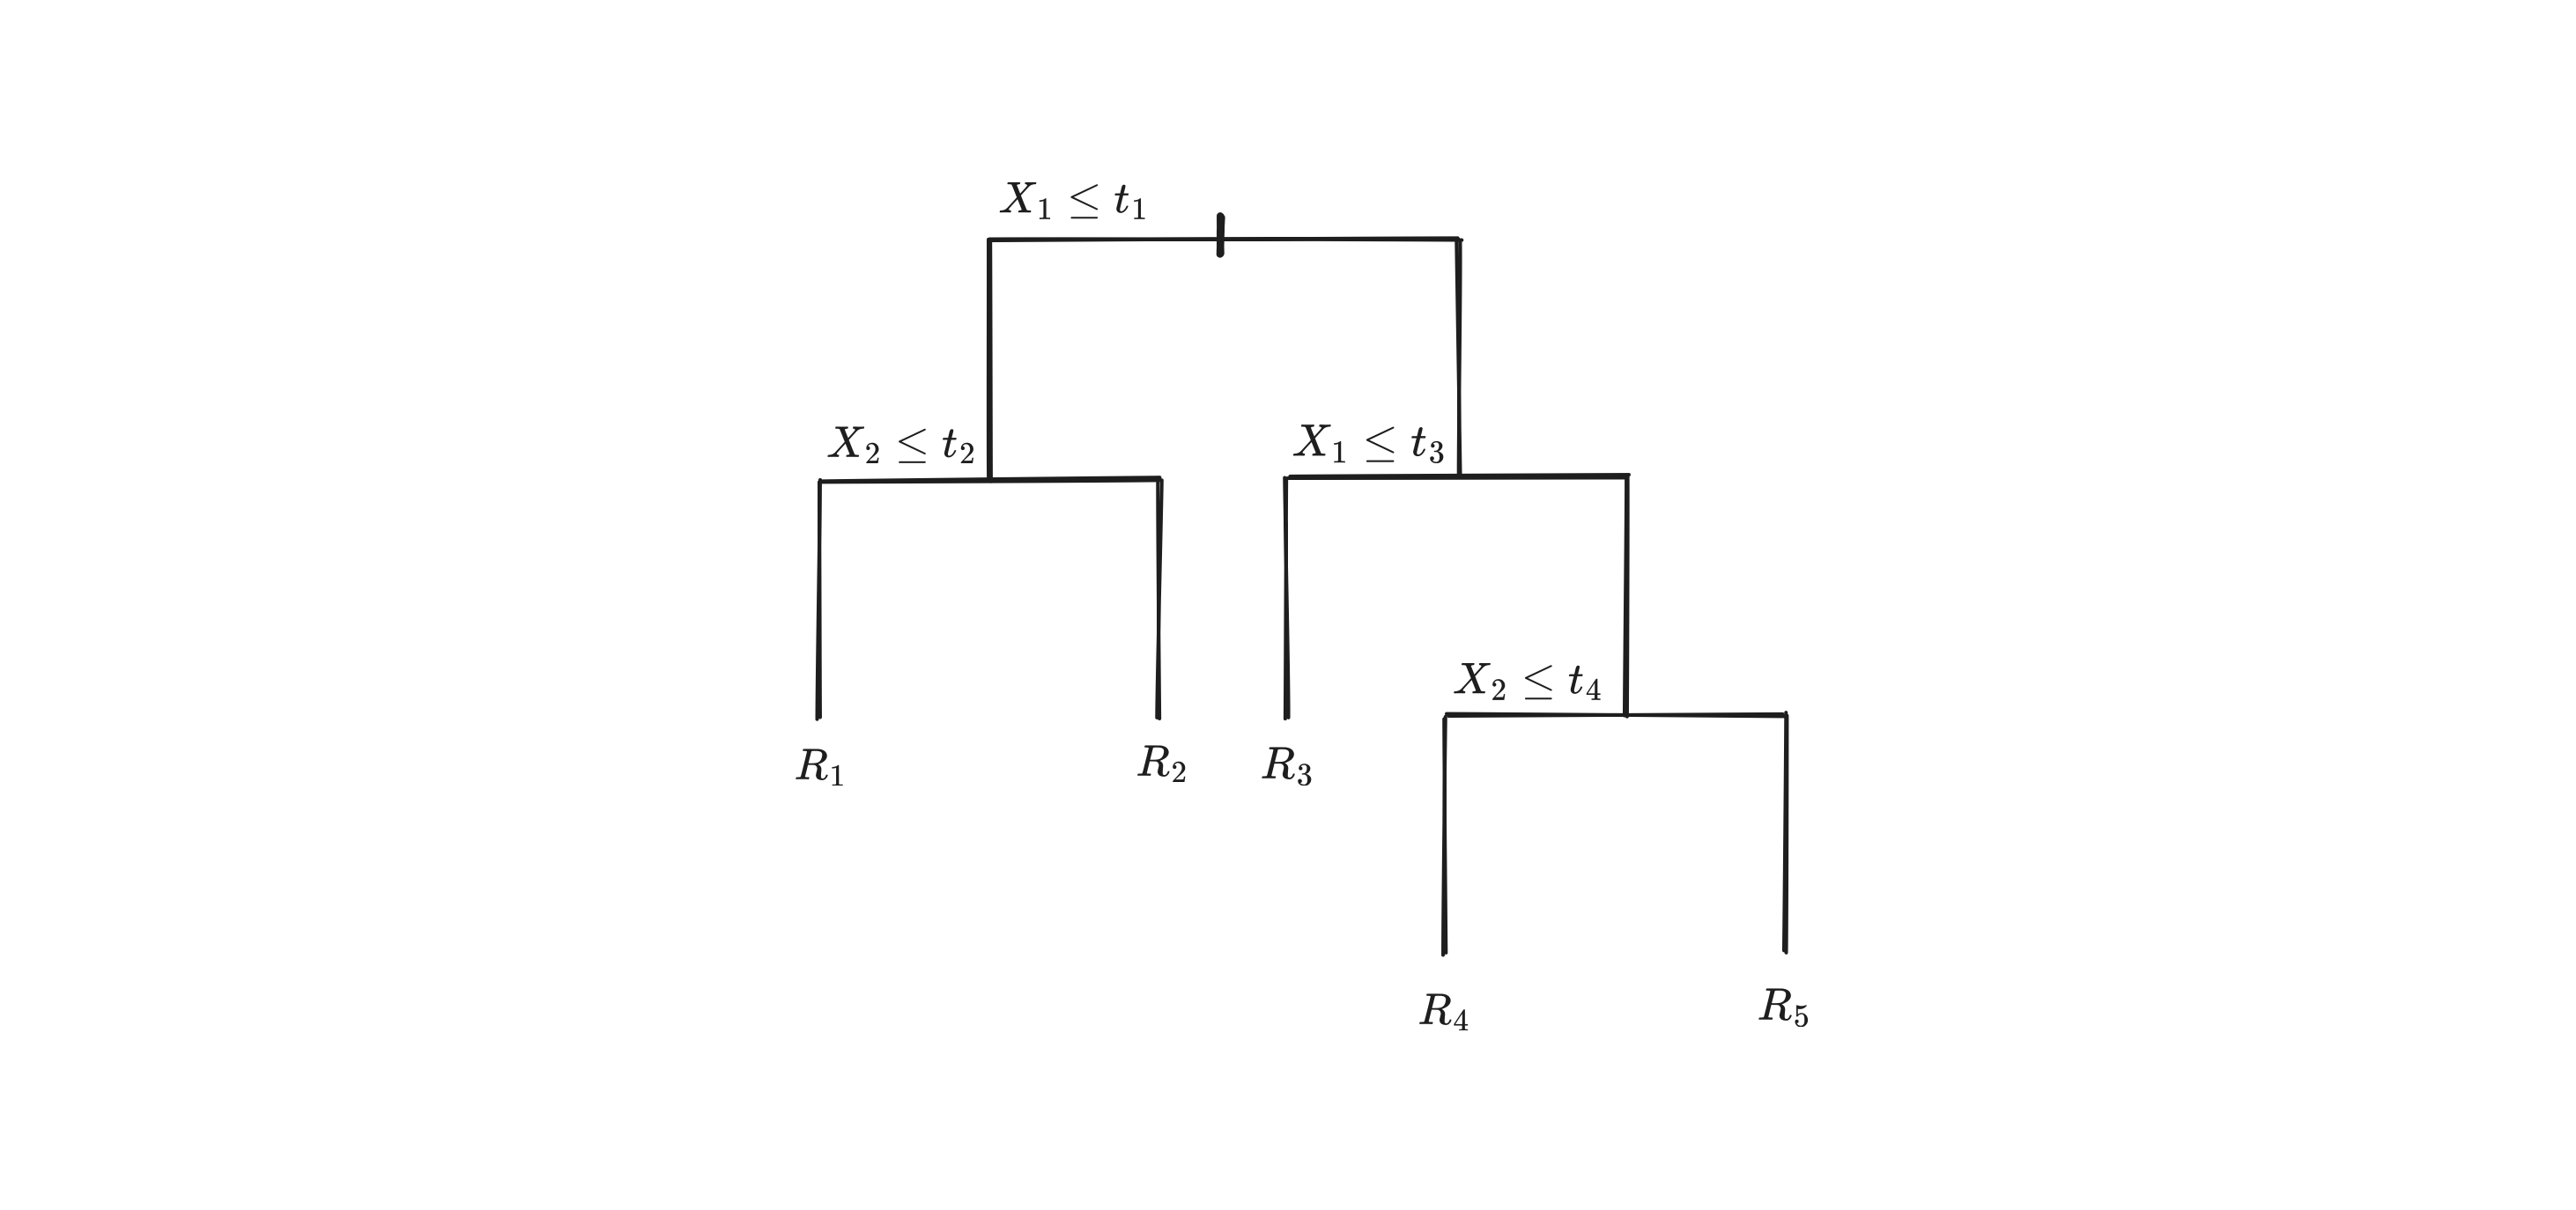

**A**:

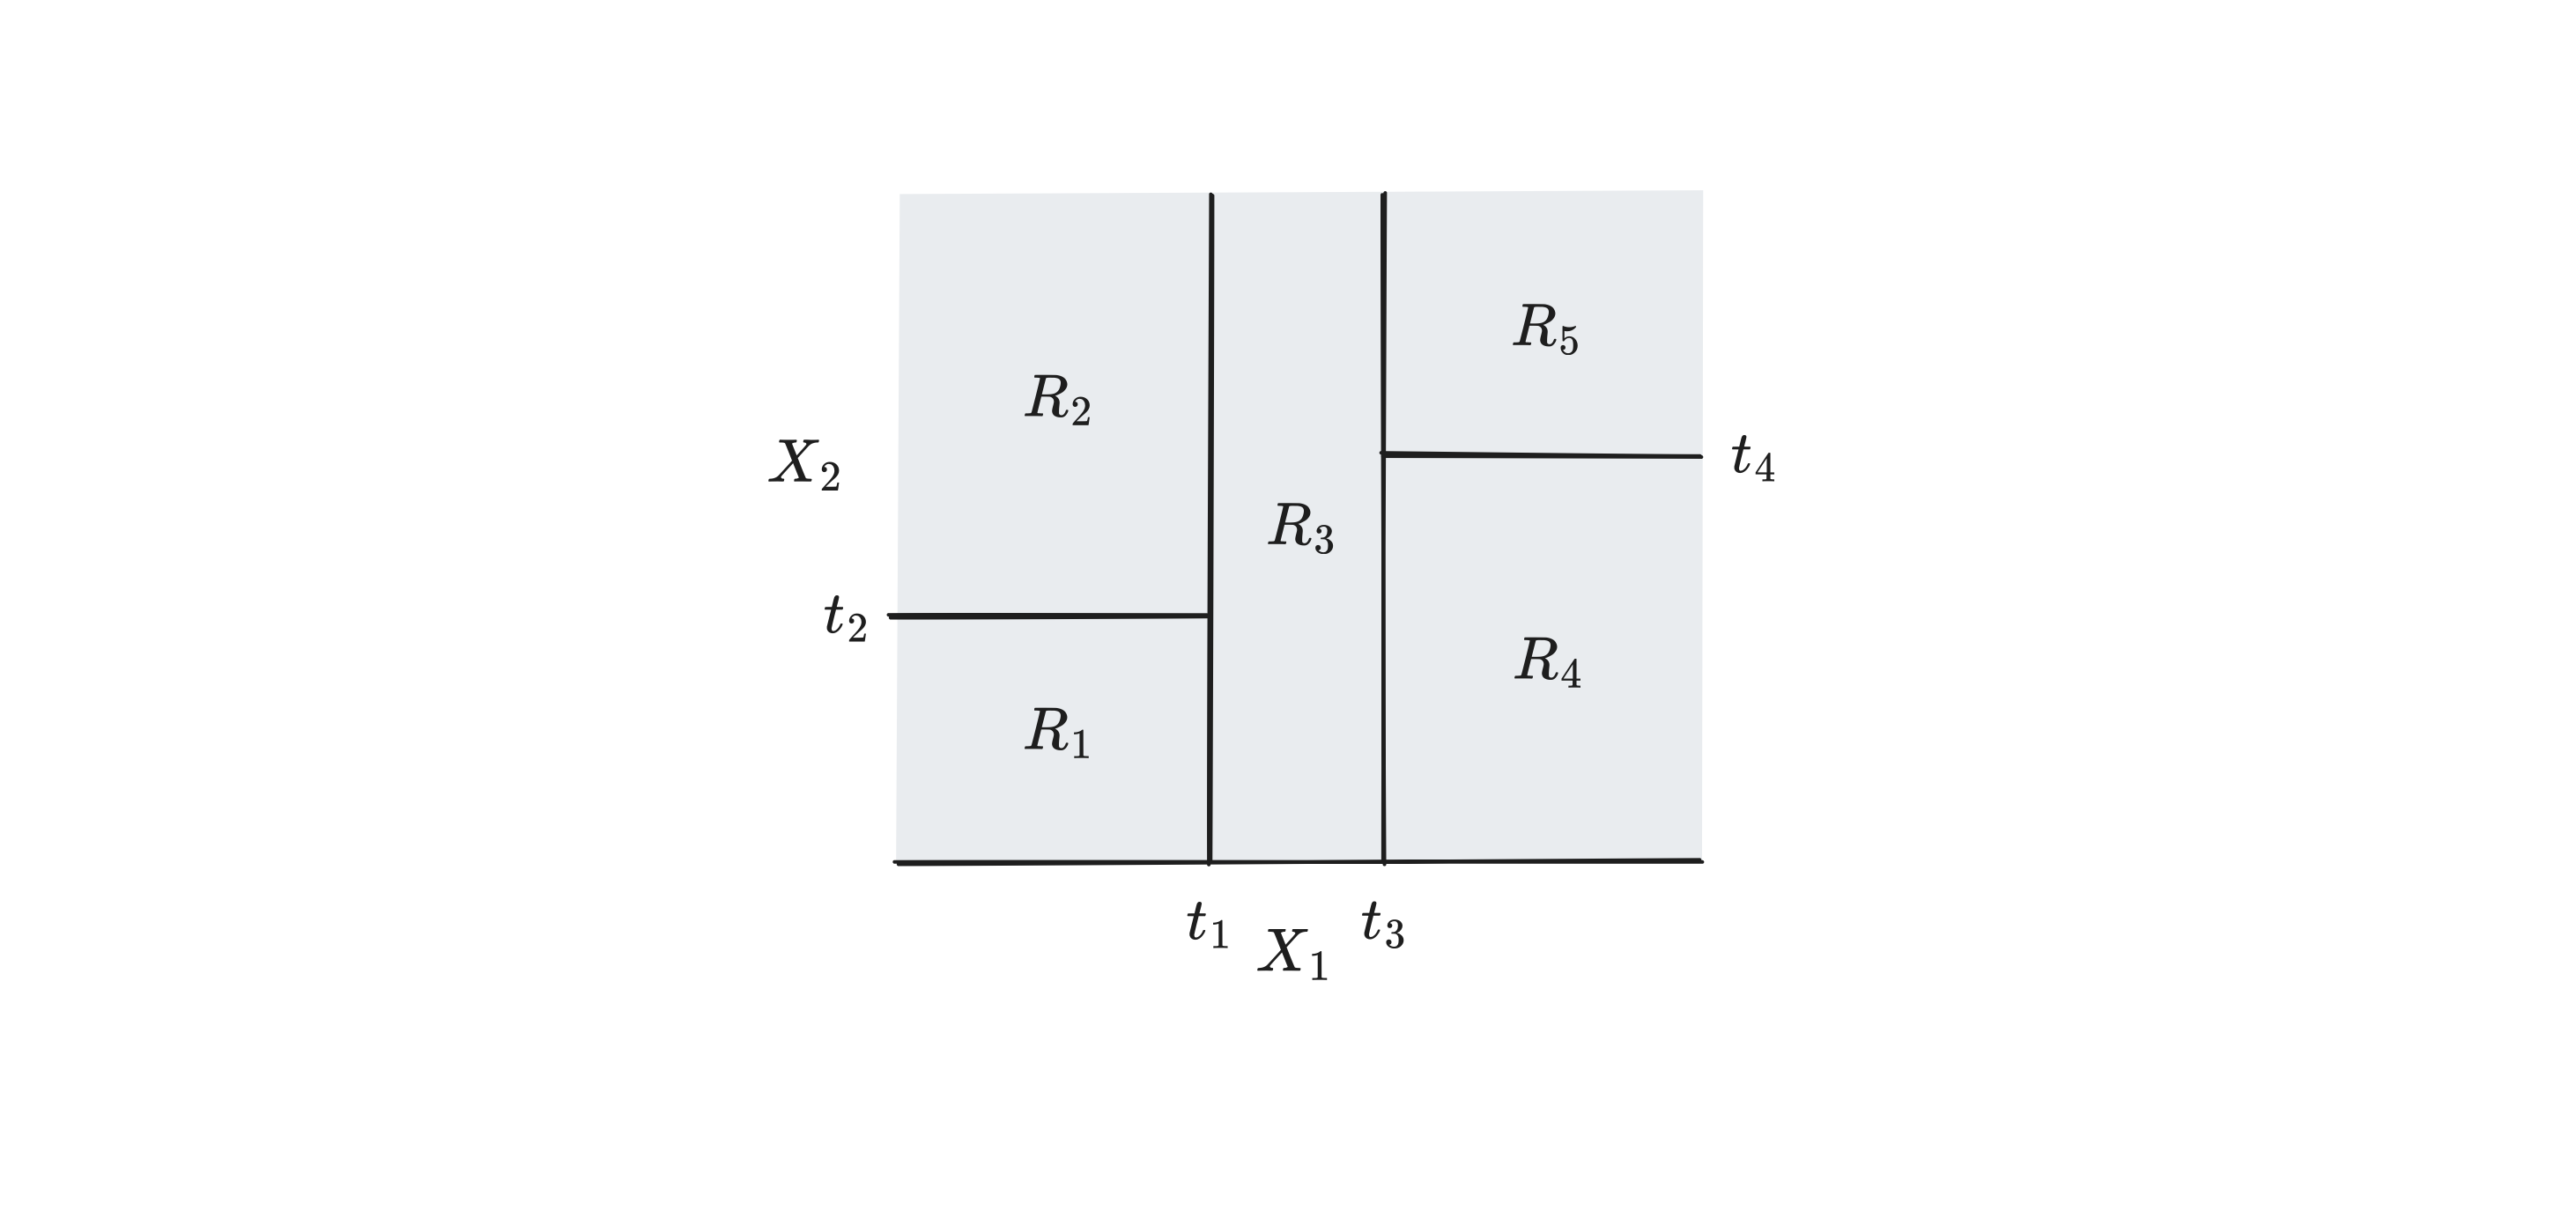

---

**Q:** How would you represent the decision tree in the diagram below using `Split` and `Leaf`?

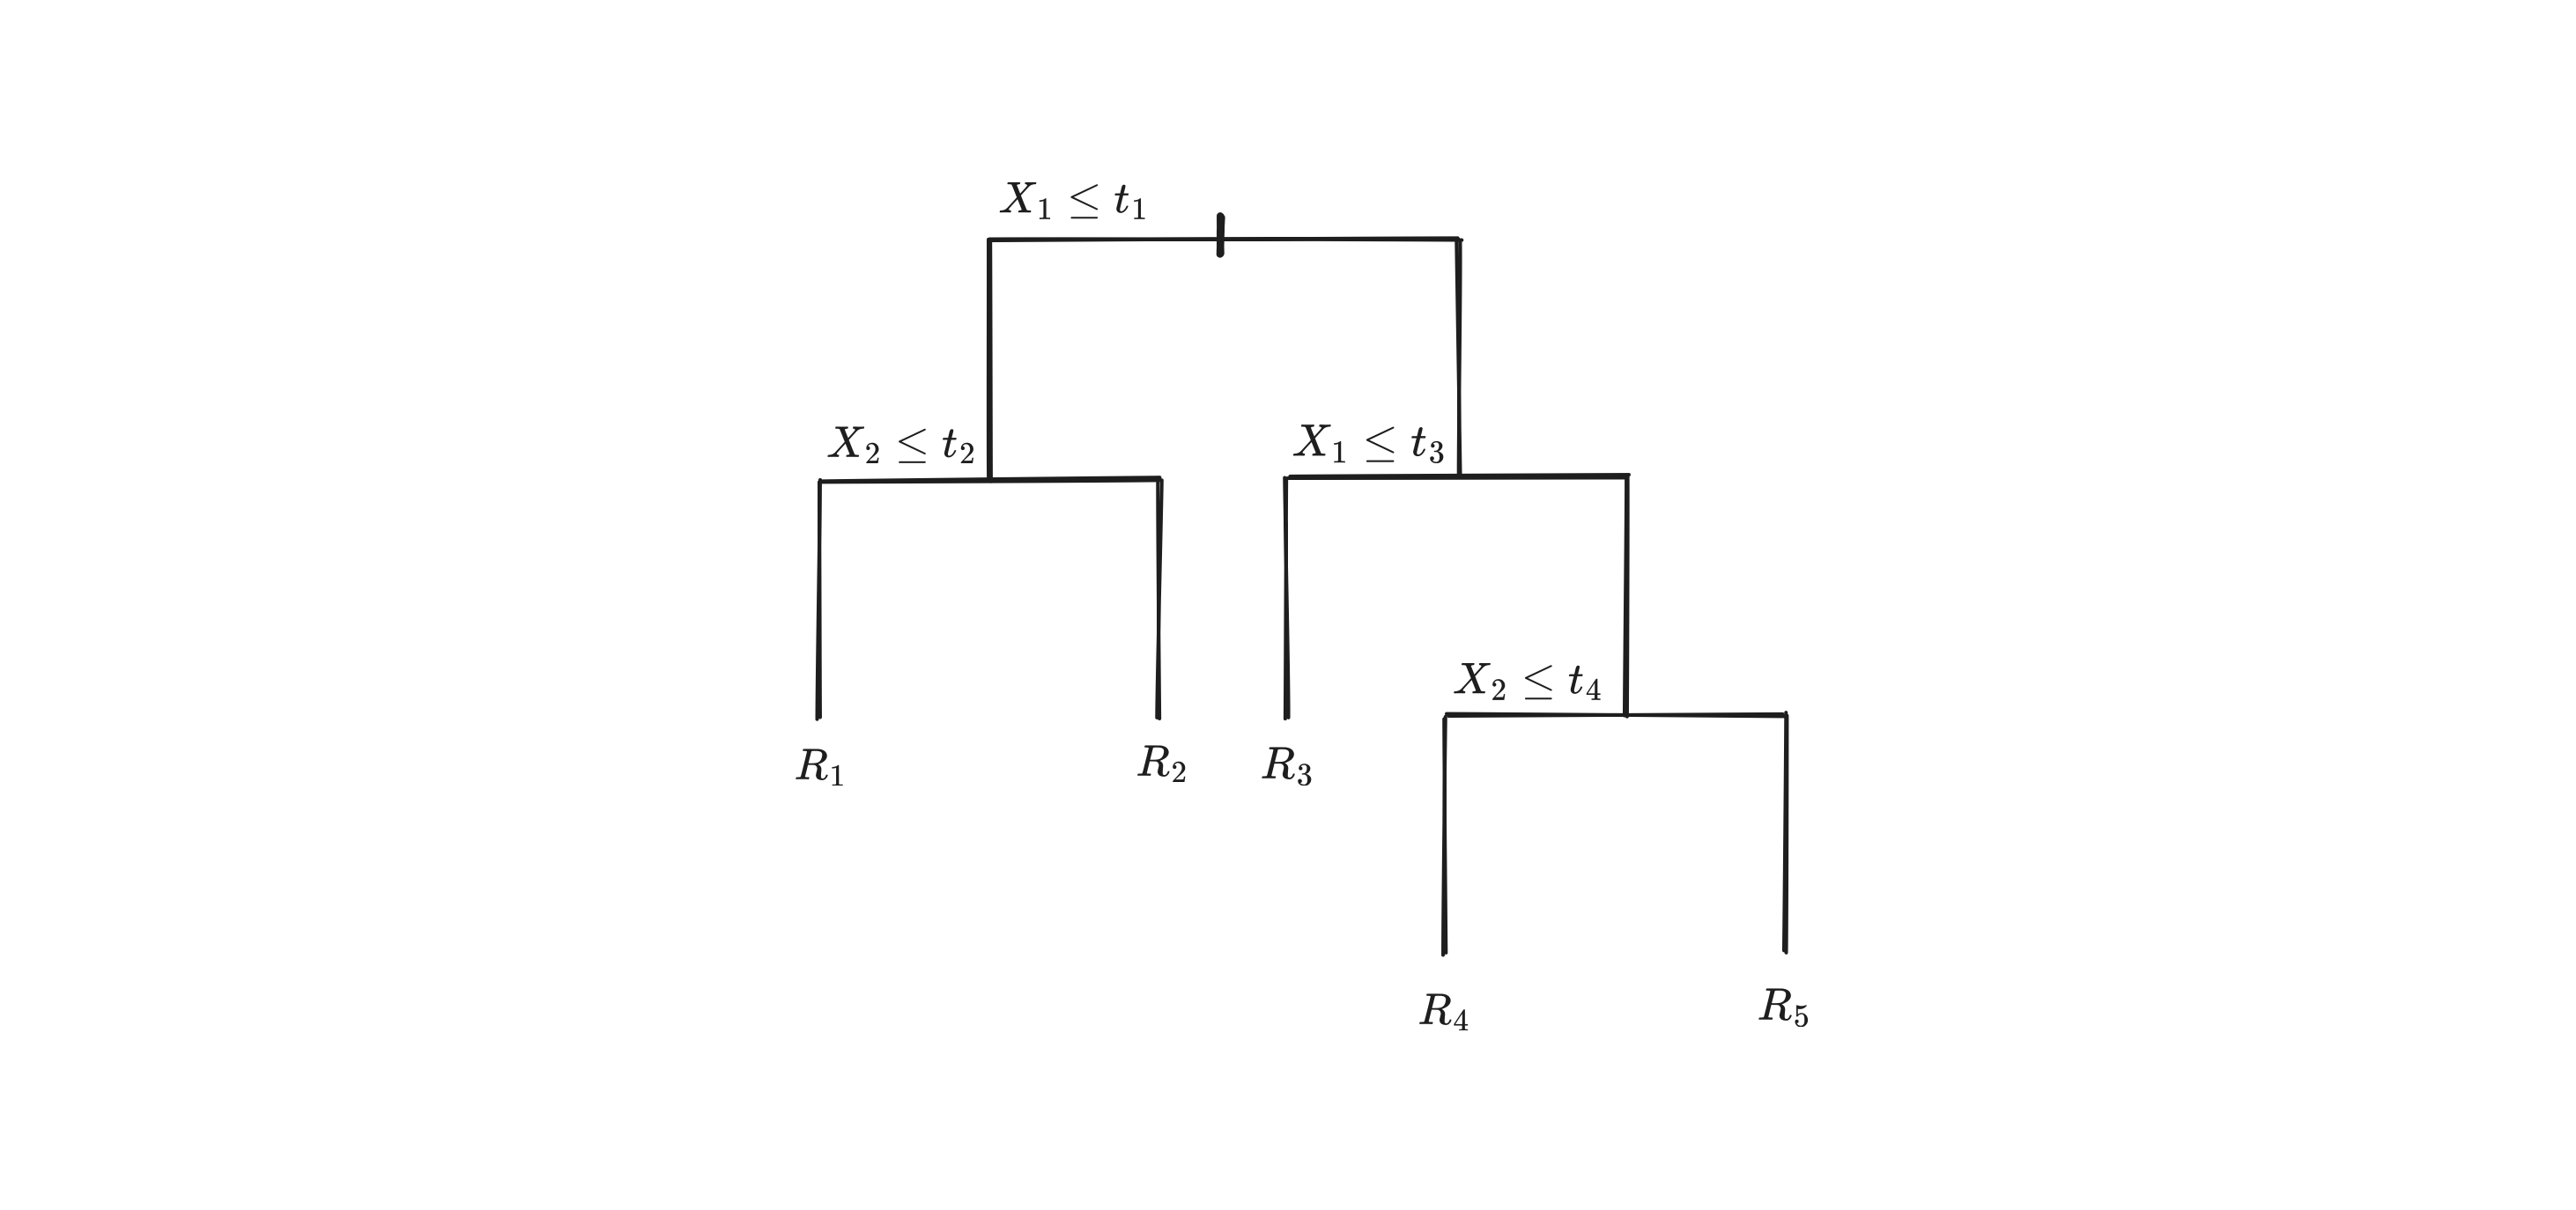

**A**: See below

---

In [1]:
from typing import Any, NamedTuple

class Leaf(NamedTuple):
    value: Any

class Split(NamedTuple):
    attribute: str
    subtrees: dict

Split("x1_le_t1", {
    True: Split("x2_le_t2", {
            True: Leaf("R1"),
            False: Leaf("R2")
    }),
    False: Split("x1_le_t3", {
        True: Leaf("R3"),
        False: Split("x2_le_t4", {
            True: Leaf("R4"),
            False: Leaf("R5")
        })
    })
})

Split(attribute='x1_le_t1', subtrees={True: Split(attribute='x2_le_t2', subtrees={True: Leaf(value='R1'), False: Leaf(value='R2')}), False: Split(attribute='x1_le_t3', subtrees={True: Leaf(value='R3'), False: Split(attribute='x2_le_t4', subtrees={True: Leaf(value='R4'), False: Leaf(value='R5')})})})

**Q:** Explain formally how a decision tree classifier assigns a label

**A:**

1. Partition the feature space into $M$ regions $R_1, R_2, \ldots, R_M$
2. For each region $R_m$, assign a label $c_m$
3. The prediction is given by
$$\hat{f}(x) = \sum_{m=1}^M c_m \cdot \mathrm{1}(x \in R_m)$$

---

**Q**: For any given feature with $N$ data points, how many unique thresholds do we need to test to find the best possible split?

**A**: $N-1$

---

**Q**: For a classification task with dataset
$$
\big\{ (x_1, y_1), (x_2, y_2), \ldots, (x_N, y_N) \big\},
$$
how is the misclassification error defined for a given region $R_m$

**A**: 
$$
\frac{1}{N_m} \sum_{i \in R_m} \mathrm{1}(y_i \neq c_m),
$$
where $N_m$ is the number of data points in region $R_m$ and $c_m$ is the predicted class for region $R_m$

---

**Q**: For a classification task with dataset
$$
\big\{ (x_1, y_1), (x_2, y_2), \ldots, (x_N, y_N) \big\},
$$
how is the gini index defined for a given region $R_m$

**A**: 
$$
\sum_{k=1}^K\hat{p}_k (1 - \hat{p}_k)
$$
where $\hat{p}_k$ is the fraction of data points in region $R_m$ with class label $k$

---

**Q**: For a classification task with dataset
$$
\big\{ (x_1, y_1), (x_2, y_2), \ldots, (x_N, y_N) \big\},
$$
how is the cross entropy defined for a given region $R_m$

**A**: 
$$
-\sum_{k=1}^K \hat{p}_k \log(\hat{p}_k)
$$
where $\hat{p}_k$ is the fraction of data points in region $R_m$ with class label $k$

---

**Q**: In a regression tree, how is the predicted value $\hat{c}_m$ determined for a given region $R_m$?

**A**: 
$$
\hat{c}_m = \operatorname{mean} \left( y_i \mid x_i \in R_m \right)
$$

---

**Q**: On what criterion does a regression tree make a split

**A**: Sum of squared error

---

**Q**: Explain the process of Bagging

**A**:
1. Draw $m$ bootstrap samples from training data
2. Train a model on each sample
3. Aggregate the resulting predictions

---

**Q**: What are the factors that affect the variance of a bagged ensemble?

**A**:
- Number of models
- Pairwise correlation between the models

---

**Q**: How can we reduce the variance of a bagged ensemble?

**A**:
- Increase the number of models
- Decrease the pairwise correlation between the models

---

**Q**: What is a random forest?

**A**: A random forest is a bagged ensemble of trees, each limited to a random subset of features

---

**Q**: Explain the process of Boosting

**A**:
1. Train a model on the given dataset
2. Create a new dataset that emphasizes the data points the previous model got wrong.
3. Repeat the process sequentially, with each new model correcting its predecessor's errors, and combine them to form a final model

---

**Q**: In a tree, what criterion is used to determine feature importance?

**A**: Mean decrease impurity

---

**Q**: In a tree, how is feature importance determined?

**A**: A feature is considered important if it has a high *mean decrease impurity*

---

**Q**: What is the formula for mean decrease impurity

**A**:
$$
I_p - p_l I_l - p_r I_r,
$$
where:

- $I_p$ is the impurity of the parent node
- $I_l$ is the impurity of the left child
- $I_r$ is the impurity of the right child
- $p_r$ is the proportion of data points in the right child
- $p_l$ is the proportion of data points in the left child

---

**Note**: In a random forest, each tree is trained on only a subset of features. This means for each tree, while splitting a node, we only consider a subset of features. This does not mean that each tree is restricted to a subset of features in its entire life. So a single tree can *potentially* use all features across its various nodes.

### Coding Questions

**Q**: Write a code snippet to compute the best split based on gini index for a binary classification task

**A**: Answer is below

In [2]:
def compute_gini_index(df, feature, threshold, target_feature):
    total_samples = df.shape[0]
    
    left_sample = df[df[feature] <= threshold]
    right_sample = df[df[feature] > threshold]

    left_frac = left_sample.shape[0] / total_samples
    right_frac = 1 - left_frac

    gini_left = 0
    if left_frac > 0:
        p_frac_left = left_sample[target_feature].mean() # we assume the target feature is binary
        gini_left = p_frac_left * (1 - p_frac_left)

    gini_right = 0
    if right_frac > 0:
        p_frac_right = right_sample[target_feature].mean()
        gini_right = p_frac_right * (1 - p_frac_right)

    return left_frac * gini_left + right_frac * gini_right

def get_best_split(df, target_feature):
    features = df.columns

    best_impurity = np.inf
    best_feature = None
    best_threshold = None

    for feature in features:
        
        if feature == target_feature:
            continue
            
        thresholds = df[feature].unique()
        for threshold in thresholds:
            impurity = compute_gini_index(df, feature, threshold, target_feature)

            if impurity < best_impurity:
                best_feature = feature
                best_threshold = threshold

    return best_impurity, best_feature, best_threshold

### Gradient Boosting

Gradient boosting draws parallels with gradient descent. At the $m$-th step, we want the predictor to be of the form:
$$
F_m(x) = F_{m-1}(x) - \gamma \sum_{i=1}^N \nabla_{F_{m-1}} \big[ L \left( y_i, F_{m-1}(x_i)  \right) \big],
$$
where our dataset is represented as:
$$
\big\{ (x_1, y_1), (x_2, y_2), \ldots, (x_N, y_N) \big\},
$$
and $L(y, \hat{y})$ is our loss function.

Consider the gradient:
$$
\sum_{i=1}^N \nabla_{F_{m-1}} \big[ L \left( y_i, F_{m-1}(x_i)  \right) \big]
$$
The expression looks daunting, but
$$
\nabla_{F_{m-1}} \big[ L \left( y, F_{m-1}(x)  \right) \big]
$$
is simply the gradient of $L$ evaluated at $F_{m-1}(x)$. So if
$$
L(y, \hat{y}) = \frac{1}{2} (y - \hat{y})^2,
$$
then
$$
\begin{align*}
\nabla_{F_{m-1}} \big[ L \left( y, F_{m-1}(x)  \right) \big] &= \frac{\partial L(y, \hat{y})}{\partial \hat{y}},
\end{align*}
$$
where $\hat{y} = F_{m-1}(x)$. This can be evaluated as:
$$
\frac{\partial L(y, \hat{y})}{\partial \hat{y}} = - (y - \hat{y}),
$$
which is essentially the residual.

During inference on the test set, there's no way we can find
$$
\nabla_{F_{m-1}} \big[ L \left( y_i, F_{m-1}(x_i) \right) \big]
$$
So instead, during training, we fit a weak learner to approximate the negative gradient. Define
$$
r_{im} = - \nabla_{F_{m-1}} \big[ L \left( y_i, F_{m-1}(x_i) \right) \big].
$$
Then, the idea is to fit a weak learner $h_m$ to the dataset
$$
\big\{ (x_1, r_{1m}), (x_2, r_{2m}), \ldots, (x_N, r_{Nm}) \big\}.
$$
So now the model at the $m$-th step can be defined as:
$$
F_m(x) = F_{m-1}(x) + \gamma h_m(x_i)
$$

To find $\gamma$, we use a process similar to backtracking in gradient descent i.e., an optimal $\gamma$ should minimise the objective:
$$
\sum_{i=1}^N L(y_i, F_m(x_i))
$$

##### Example

Define $L$ to be the squared loss, then (assuming the target is a scalar):
$$
r_{im} = y_i - F_{m-1}(x_i)
$$
is just the residual. If $h_m(x_i) \approx r_{im}$ and $\gamma = 1$, then:
$$
\begin{align*}
F_m(x_i) &= F_{m-1}(x_i) + h_m(x_i) \\[4pt]
&\approx F_{m-1}(x_i) + y_i - F_{m-1}(x_i) \\[4pt]
&\approx y_i
\end{align*}
$$

So if the weak learner predicts the residual accurately, then the model predicts the target accurately

#### Gradient Boosted Tree

In gradient boosted tree, the weak learner $h_m$ is a regression tree. So now the model can be rewritten as:
$$
\begin{align*}
F_m(x) &= F_{m-1}(x) + \gamma_m \sum_{j=1}^M c_{jm} \mathrm{1}(x_i \in R_{jm}) \\[4pt]
&= F_{m-1}(x) + \sum_{j=1}^M (\gamma_m c_{jm}) \mathrm{1}(x_i \in R_{jm}) \\[4pt]
\end{align*}
$$
Once we fit the weak learner $h_m$ on the negative gradient, the regions $R_{1m}, \ldots, R_{Mm}$ become known. The prediction values $c_{1m}, \ldots, c_{Mm}$ can be learnt later. Here, instead, we learn the product $\gamma_m c_{jm}$ together by minimising the objective
$$
\gamma_m c_{jm} = \underset{\beta}{\operatorname{argmin}} \sum_{x_i \in R_{jm}} L\big(y_i, F_{m-1}(x_i) + \beta \big)
$$
for each $j$

#### Initialisation

$F_0$ is initialised as a constant function that minimises the empirical risk:
$$
F_0(x) =  \underset{\alpha}{\operatorname{argmin}} \sum_{i=1}^N L\big(y_i, \alpha \big)
$$

### ControlBurn

**Q**: What is the idea behind $l_1$ post processing?

**A**: Given a set of $m$ ensemble learners $T_1, \ldots, T_m$, the idea is to remove redundant learners by minimizing the objective
$$
\sum_{i=1}^N L\left(y_i, \alpha_0 + \sum_{j=1}^m \alpha_j T_j(x_i) \right) + \lambda \sum_{k=1}^m \| \alpha_k \|_1,
$$
where $\lambda > 0$ is the regularization parameter

---

**Q**: What is the key property of LASSO regression?

**A**: LASSO regression selects a single feature from a group of highly correlated features

---

**Q**: What is the problem with mean decrease impurity for feature selection?

**A**: Suppose we have a group of highly correlated features that are also important. Then, the mean decrease impurity for these correlated features will be close. This means an important feature that isn't correlated with these features will be pushed down in feature importance

---

The solution is to select a subset of learners such that the resulting ensemble doesn't use all the features. Note that in bagging, a learner uses only a subset of features.

This can be done by minimizing the objective:
$$
\frac{1}{N} L(y, Aw) + \lambda \sum_{j=1}^m u_j w_j, \quad \text{subject to } w \geq 0
$$

Here $A$ is the $N \times m$ prediction matrix i.e., it contains predictions made by all the $m$ learners for all the $N$ data points. $w$ is the weight vector that is intended to be sparse, and for each $k$, $u_k$ represents the number of features used by learner $k$

Let's look at the penalty term:
$$
\lambda \sum_{j=1}^m u_j w_j
$$
Here, we're heavily penalizing learners that use a lot of features

The constraint $w \geq 0$ ensures the learners are combined in an additive fashion.

Note that the above method fails when every learner uses all the features. In a random forest, this is most likely to happen when each tree is very deep. To solve this, we need to grow a *diverse forest*

A diverse forest is a one where each tree uses only a subset of features. To grow a diverse forest, we need to restrict the depth of each tree without sacrificing the performance

---

Didn't feel the need to jot down the algorithm

---

**Q**: What is the intuitive idea behind filter-based feature selection algorithms?

**A**: Features that are correlated with the response are preserved while uncorrelated features are removed.

---

**Q**: What is the intuitive idea behind wrapper-based feature selection algorithms?

**A**: Wrapper-based feature selection algorithms iteratively select features through retraining the model across different feature subsets.

---